<a href="https://colab.research.google.com/github/Angelenguems/Projet_IRM/blob/Francois_Projet/application_du_clahe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

pip install --upgrade keras tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 29.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently t

# **Classification binaire des tumeurs cérébrales à partir d’images IRM**

##  **1. Introduction**


L’analyse des images médicales, notamment les images par résonance magnétique (IRM), joue un rôle essentiel dans le diagnostic des pathologies cérébrales. La détection des tumeurs cérébrales est une tâche complexe qui nécessite une expertise médicale approfondie et peut être sujette à des variations d’interprétation.

Dans ce contexte, l’utilisation des techniques d’apprentissage profond permet d’automatiser l’analyse des images et d’assister les professionnels de santé dans le processus de diagnostic.

L’objectif de ce projet est de développer un modèle de classification capable de distinguer automatiquement les images IRM contenant une tumeur (tumor) de celles n’en contenant pas (no_tumor). Pour cela, une approche basée sur le transfert d’apprentissage a été adoptée en utilisant le modèle pré-entraîné ResNet50.

Afin d’améliorer les performances du modèle, plusieurs techniques ont été mises en œuvre, notamment l’amélioration du contraste des images avec CLAHE, l’augmentation des données, le fine-tuning du modèle, ainsi que l’optimisation du seuil de décision. Enfin, une analyse d’interprétabilité a été réalisée à l’aide de Grad-CAM afin de visualiser les régions de l’image utilisées par le modèle pour prendre ses décisions.

## **2. Importation des bibliothèques**

In [2]:
# Manipulation de données
import os
import random
import numpy as np
import pandas as pd
import gdown
import zipfile
import shutil

# Gestion des chemins
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Traitement d'images
import cv2
from PIL import Image

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# Métriques
from sklearn.metrics import (classification_report,confusion_matrix,precision_score,recall_score,f1_score,accuracy_score)

## **3. Chargement et organisation des données**
Dans cette section, le dataset est téléchargé, extrait, puis restructuré en un problème de classification binaire. Les trois classes tumorales (`glioma_tumor`, `meningioma_tumor` et `pituitary_tumor`) sont fusionnées dans une seule classe `tumor`, tandis que la classe `no_tumor` est conservée telle quelle. Une nouvelle arborescence de données est ensuite créée afin de faciliter l’entraînement du modèle.
### 3.1 téléchargement et extraction du dataset

In [3]:
file_id = "1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc"
url = f"https://drive.google.com/uc?id={file_id}"
output = "dataset.zip"

gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, "r") as zip_ref:
    zip_ref.extractall("/content/")

# Détection automatique du dossier dataset
possible_dirs = [d for d in os.listdir("/content") if "brain" in d.lower()]

if len(possible_dirs) > 0:
    DATA_PATH = Path(f"/content/{possible_dirs[0]}")
else:
    raise Exception("Dataset folder not found")

print("DATA_PATH =", DATA_PATH)

Downloading...
From (original): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc
From (redirected): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc&confirm=t&uuid=9f749657-4ece-44aa-876f-0d41282e3126
To: /content/dataset.zip
100%|██████████| 94.3M/94.3M [00:02<00:00, 36.2MB/s]


DATA_PATH = /content/brain-tumor-classification-mri


### 3.2 Réorganisation du dataset en classification binaire

In [4]:
src_root = DATA_PATH
dst_root = Path("/content/Binary")

splits = ["Training", "Testing"]
tumor_folders = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor"]
no_tumor_folder = "no_tumor"

# Suppression du dossier cible s'il existe déjà
if dst_root.exists():
    shutil.rmtree(dst_root)

# Création de l'arborescence binaire
for split in splits:
    (dst_root / split / "tumor").mkdir(parents=True, exist_ok=True)
    (dst_root / split / "no_tumor").mkdir(parents=True, exist_ok=True)

def safe_copy(src_file: Path, dst_dir: Path):
    dst_file = dst_dir / src_file.name

    if dst_file.exists():
        dst_file = dst_dir / f"{src_file.stem}_{abs(hash(str(src_file))) % 10**8}{src_file.suffix}"

    shutil.copy2(src_file, dst_file)

# Fusion des classes tumorales
for split in splits:
    for cls in tumor_folders:
        cls_path = src_root / split / cls
        if cls_path.exists():
            for img in cls_path.rglob("*"):
                if img.is_file():
                    safe_copy(img, dst_root / split / "tumor")

    cls_path = src_root / split / no_tumor_folder
    if cls_path.exists():
        for img in cls_path.rglob("*"):
            if img.is_file():
                safe_copy(img, dst_root / split / "no_tumor")

print("Fusion binaire terminée.")
print("Dossier source :", src_root)
print("Classes Training :", os.listdir(dst_root / "Training"))
print("Classes Testing  :", os.listdir(dst_root / "Testing"))

Fusion binaire terminée.
Dossier source : /content/brain-tumor-classification-mri
Classes Training : ['tumor', 'no_tumor']
Classes Testing  : ['tumor', 'no_tumor']


### 3.3 Vérification du nombre d’images

In [5]:
print("Nombre d'images Training/tumor    :", len(list((dst_root / "Training" / "tumor").glob("*"))))
print("Nombre d'images Training/no_tumor :", len(list((dst_root / "Training" / "no_tumor").glob("*"))))
print("Nombre d'images Testing/tumor     :", len(list((dst_root / "Testing" / "tumor").glob("*"))))
print("Nombre d'images Testing/no_tumor  :", len(list((dst_root / "Testing" / "no_tumor").glob("*"))))

Nombre d'images Training/tumor    : 2475
Nombre d'images Training/no_tumor : 395
Nombre d'images Testing/tumor     : 289
Nombre d'images Testing/no_tumor  : 105


### 3.4 Chargement des datasets TensorFlow

In [6]:
train_dir = "/content/Binary/Training"
test_dir = "/content/Binary/Testing"

print("Classes train :", os.listdir(train_dir))
print("Classes test  :", os.listdir(test_dir))

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=False
)

Classes train : ['tumor', 'no_tumor']
Classes test  : ['tumor', 'no_tumor']
Found 2870 files belonging to 2 classes.
Found 394 files belonging to 2 classes.


## **4. Analyse exploratoire et qualité des images**

Avant l’entraînement du modèle, une vérification de la qualité des images est effectuée. Cette étape permet d’identifier d’éventuelles images corrompues ainsi que d’examiner la cohérence du dataset. Une telle démarche contribue à fiabiliser le pipeline d’apprentissage.

### 4.1 Suppression des images corrompues

In [7]:
train_dir = Path("/content/Binary/Training")
test_dir = Path("/content/Binary/Testing")

def remove_corrupted_images(folder: Path):
    removed = 0

    for img_path in folder.rglob("*"):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                print("Image corrompue supprimée :", img_path)
                img_path.unlink()
                removed += 1

    return removed

removed_train = remove_corrupted_images(train_dir)
removed_test = remove_corrupted_images(test_dir)

print("\nNettoyage terminé")
print("Images supprimées - Training :", removed_train)
print("Images supprimées - Testing  :", removed_test)


Nettoyage terminé
Images supprimées - Training : 0
Images supprimées - Testing  : 0


In [8]:
print("Nombre d'images Training/tumor    :", len(list((train_dir / "tumor").glob("*"))))
print("Nombre d'images Training/no_tumor :", len(list((train_dir / "no_tumor").glob("*"))))
print("Nombre d'images Testing/tumor     :", len(list((test_dir / "tumor").glob("*"))))
print("Nombre d'images Testing/no_tumor  :", len(list((test_dir / "no_tumor").glob("*"))))

Nombre d'images Training/tumor    : 2475
Nombre d'images Training/no_tumor : 395
Nombre d'images Testing/tumor     : 289
Nombre d'images Testing/no_tumor  : 105


### 4.3 Visualisation de quelques images

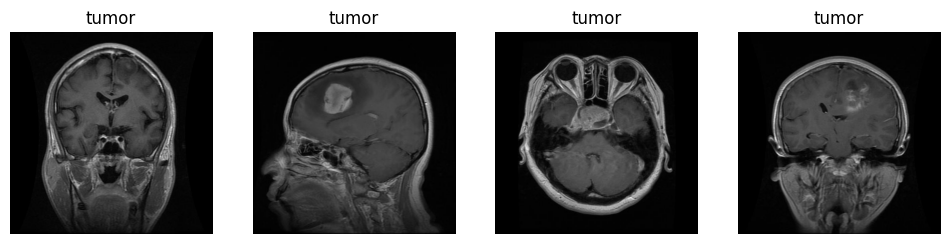

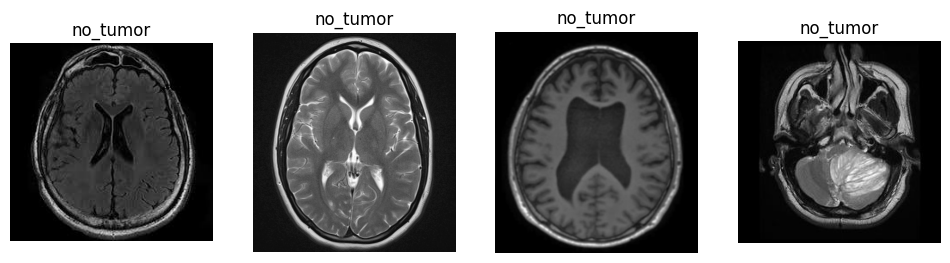

In [9]:
def show_sample_images(folder, title, n=4):
    image_paths = list(folder.glob("*"))
    selected_images = random.sample(image_paths, min(n, len(image_paths)))

    plt.figure(figsize=(12, 3))

    for i, img_path in enumerate(selected_images, 1):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(selected_images), i)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")

    plt.show()

show_sample_images(train_dir / "tumor", "tumor")
show_sample_images(train_dir / "no_tumor", "no_tumor")

## **5. Prétraitement des images avec CLAHE**

## 5.1 Histogramme de constraste avant CLAHE
Afin d’évaluer la qualité des images, une analyse du contraste a été réalisée. Le contraste est mesuré à l’aide de l’écart-type des niveaux de gris. Cette étape permet d’identifier les images présentant un contraste faible ou élevé, susceptibles d’influencer les performances du modèle.

Un histogramme est ensuite utilisé pour visualiser la distribution du contraste dans le dataset.

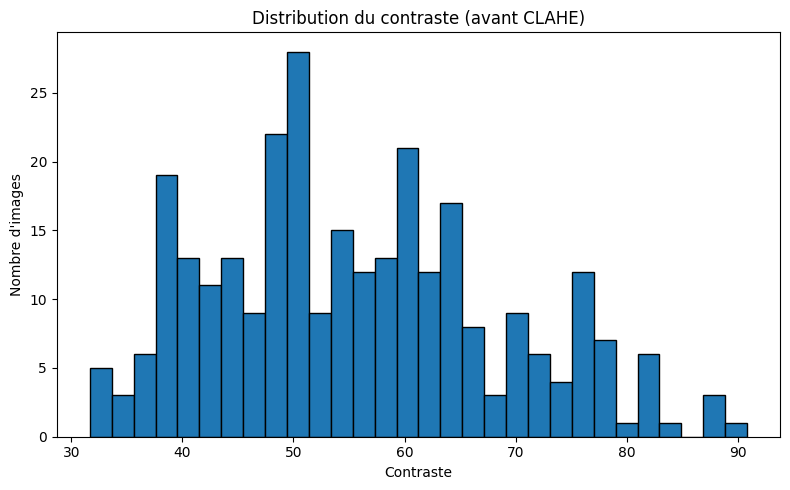

In [10]:
# Fonction de calcul du contraste avant Clahe
def contrast_score(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    return np.std(img)

# Dossier
folder = "/content/Binary/Testing/tumor"

# Calcul des contrastes
contrasts = []

for img_name in os.listdir(folder):
    path = os.path.join(folder, img_name)
    contrasts.append(contrast_score(path))

# Affichage histogramme
plt.figure(figsize=(8,5))
plt.hist(contrasts, bins=30, edgecolor="black")  # bords plus propres
plt.title("Distribution du contraste (avant CLAHE)")
plt.xlabel("Contraste")
plt.ylabel("Nombre d'images")
plt.tight_layout()  # ajuste automatiquement les marges
plt.show()

### 5.2 Détection des images extrêmes

In [11]:
low_contrast = []
high_contrast = []

for img_name in os.listdir(folder):
    path = os.path.join(folder, img_name)
    c = contrast_score(path)

    if c < 50:
        low_contrast.append(path)
    elif c > 85:
        high_contrast.append(path)

print("Images faible contraste :", len(low_contrast))
print("Images fort contraste :", len(high_contrast))

Images faible contraste : 109
Images fort contraste : 4


### 5.3 Visualisation ds images de faible contraste

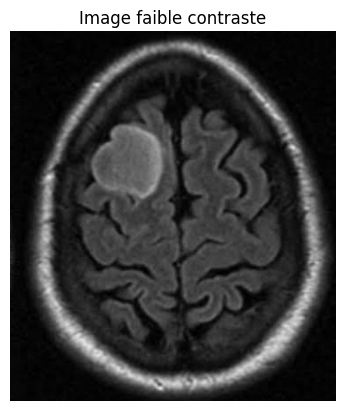

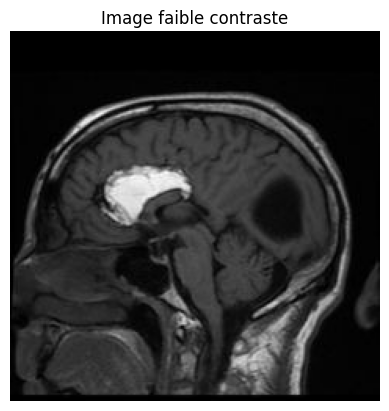

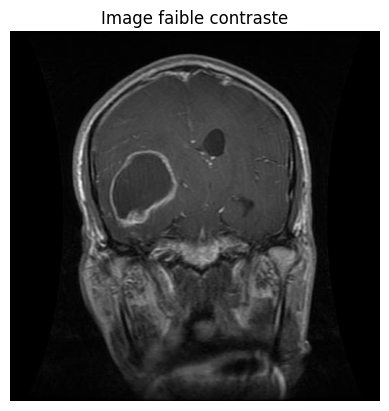

In [12]:
def show_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title("Image faible contraste")
    plt.axis("off")
    plt.show()

# afficher quelques images
for p in low_contrast[:3]:
    show_image(p)

## 5.4 Application du clahe

In [13]:
# Chemins source et destination
src_root = Path("/content/Binary")
clahe_root = Path("/content/Binary_CLAHE")

# Suppression du dossier CLAHE s'il existe déjà
if clahe_root.exists():
    shutil.rmtree(clahe_root)

# Création de l'arborescence cible
for split in ["Training", "Testing"]:
    for cls in ["tumor", "no_tumor"]:
        (clahe_root / split / cls).mkdir(parents=True, exist_ok=True)

# Fonction CLAHE
def apply_clahe_rgb(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)

    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    return img_clahe

# Application de CLAHE
count_saved = 0

for split in ["Training", "Testing"]:
    for cls in ["tumor", "no_tumor"]:
        src_folder = src_root / split / cls
        dst_folder = clahe_root / split / cls

        for img_path in src_folder.glob("*"):
            if img_path.is_file():
                img = cv2.imread(str(img_path))

                if img is None:
                    print("Impossible de lire :", img_path)
                    continue

                img_clahe = apply_clahe_rgb(img)

                save_path = dst_folder / img_path.name
                cv2.imwrite(str(save_path), img_clahe)
                count_saved += 1

print("CLAHE appliqué avec succès")
print("Nombre total d'images sauvegardées :", count_saved)
print("Nouveau dossier :", clahe_root)

CLAHE appliqué avec succès
Nombre total d'images sauvegardées : 3264
Nouveau dossier : /content/Binary_CLAHE


### 5.5 Comparaison visuelle avant / après CLAHE

Nombre images originales : 2475
Nombre images CLAHE      : 2475


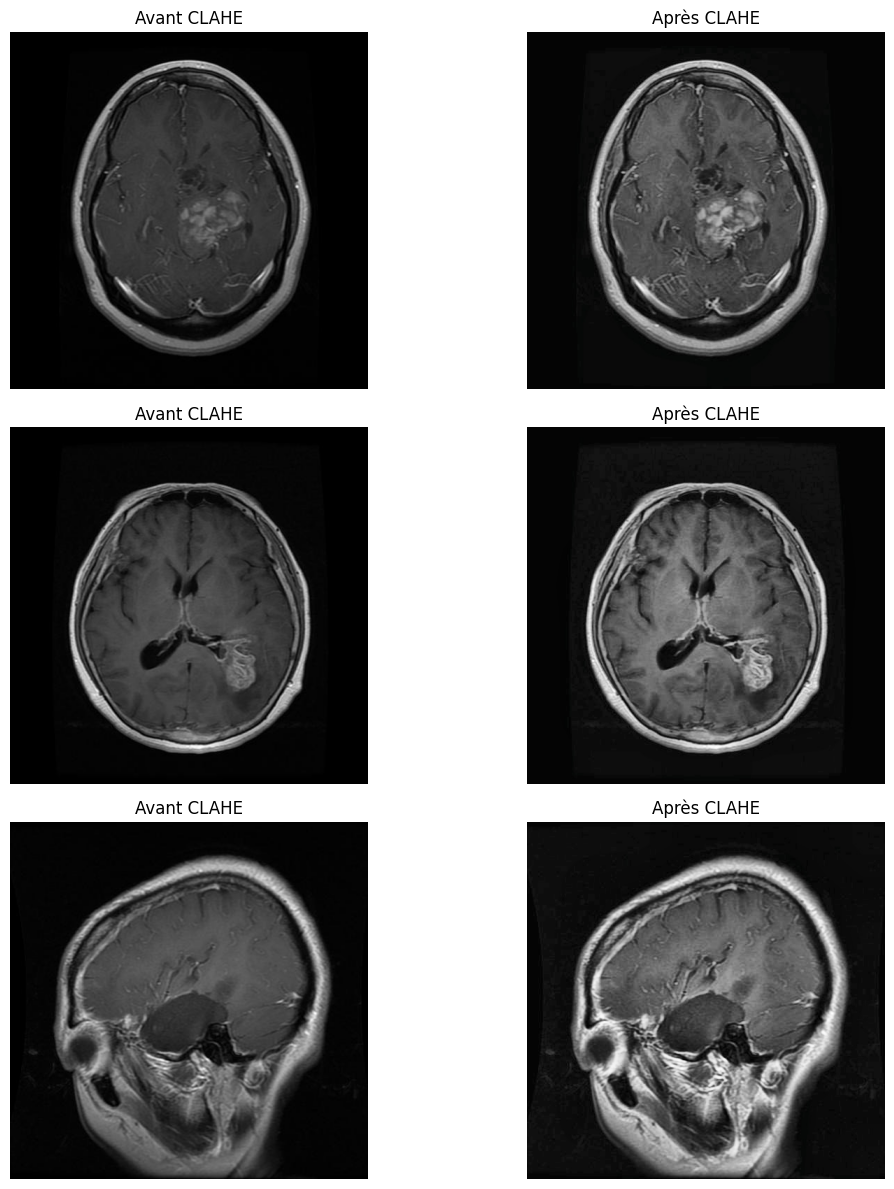

In [14]:
orig_folder = Path("/content/Binary/Training/tumor")
clahe_folder = Path("/content/Binary_CLAHE/Training/tumor")

orig_images = sorted(list(orig_folder.glob("*")))
clahe_images = sorted(list(clahe_folder.glob("*")))

print("Nombre images originales :", len(orig_images))
print("Nombre images CLAHE      :", len(clahe_images))

n = 3
plt.figure(figsize=(12, 4 * n))

for i in range(min(n, len(orig_images))):
    img_orig = cv2.imread(str(orig_images[i]))
    img_clahe = cv2.imread(str(clahe_images[i]))

    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB)

    plt.subplot(n, 2, 2 * i + 1)
    plt.imshow(img_orig)
    plt.title("Avant CLAHE")
    plt.axis("off")

    plt.subplot(n, 2, 2 * i + 2)
    plt.imshow(img_clahe)
    plt.title("Après CLAHE")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 5.6 Vérification des images corrompues après CLAHE

In [15]:
train_clahe_dir = Path("/content/Binary_CLAHE/Training")
test_clahe_dir = Path("/content/Binary_CLAHE/Testing")

def remove_corrupted_images(folder):
    removed = 0

    for img_path in folder.rglob("*"):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                print("Image corrompue supprimée :", img_path)
                img_path.unlink()
                removed += 1

    return removed

removed_train = remove_corrupted_images(train_clahe_dir)
removed_test = remove_corrupted_images(test_clahe_dir)

print("\nNettoyage CLAHE terminé")
print("Images supprimées - Training_CLAHE :", removed_train)
print("Images supprimées - Testing_CLAHE  :", removed_test)


Nettoyage CLAHE terminé
Images supprimées - Training_CLAHE : 0
Images supprimées - Testing_CLAHE  : 0


### 5.7 Comptage final des images après CLAHE

In [16]:
for split in ["Training", "Testing"]:
    for cls in ["tumor", "no_tumor"]:
        folder = Path(f"/content/Binary_CLAHE/{split}/{cls}")
        print(f"{split}/{cls} :", len(list(folder.glob('*'))))

Training/tumor : 2475
Training/no_tumor : 395
Testing/tumor : 289
Testing/no_tumor : 105


### 5.8 Histogramme de constraste après CLAHE

In [17]:
def contrast_score(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    return np.std(img)

# Dossier CLAHE
folder = "/content/Binary_CLAHE/Testing/tumor"

# Calcul
contrasts_clahe = []

for img_name in os.listdir(folder):
    path = os.path.join(folder, img_name)
    contrasts_clahe.append(contrast_score(path))

In [18]:
plt.close('all')

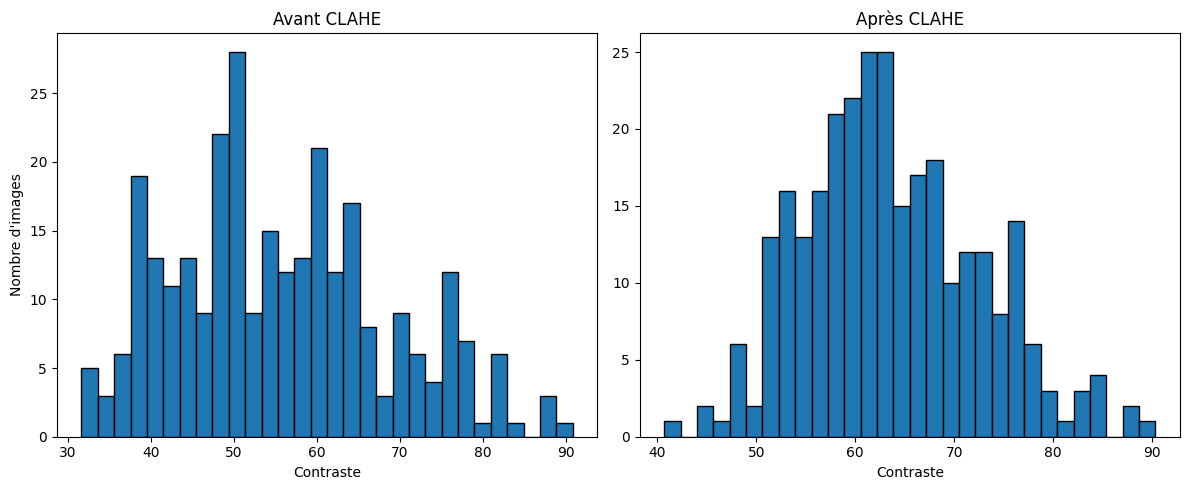

In [19]:
plt.figure(figsize=(12,5))

# Avant CLAHE
plt.subplot(1,2,1)
plt.hist(contrasts, bins=30, edgecolor="black")
plt.title("Avant CLAHE")
plt.xlabel("Contraste")
plt.ylabel("Nombre d'images")

# Après CLAHE
plt.subplot(1,2,2)
plt.hist(contrasts_clahe, bins=30, edgecolor="black")
plt.title("Après CLAHE")
plt.xlabel("Contraste")

plt.tight_layout()
plt.show()

La comparaison des distributions de contraste avant et après l’application de CLAHE met en évidence une amélioration significative de la qualité des images.

Avant CLAHE, la distribution est étalée avec un nombre important d’images à faible contraste. Après application de CLAHE, la distribution se resserre autour de valeurs plus élevées, indiquant une augmentation globale du contraste.

On observe également une réduction des images à très faible contraste, ce qui contribue à homogénéiser le dataset. Cette amélioration facilite l’extraction des caractéristiques pertinentes par le modèle et participe à l’amélioration des performances de classification.